In [12]:
import requests
import re
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt

In [13]:
# # Define GitHub paths
# github_url = "https://github.com/jamie07262/INFO-3608-PROJECT/tree/main/data/processed"
# processed_url_prefix = "https://raw.githubusercontent.com/jamie07262/INFO-3608-PROJECT/main/data/processed/"

# # Get the HTML content of the folder
# response = requests.get(github_url)
# html = response.text

# # Extract CSV filenames and remove duplicates
# csv_files = list(set(re.findall(r'href=".*?/data/processed/([^"]+\.csv)"', html)))

# # Create the directory and download the files
# !mkdir -p processed
# for file in csv_files:
#     url = processed_url_prefix + file
#     !wget -q -P processed {url}
#     print(f"Downloaded: {file}")

# print("All CSV files downloaded successfully.")

import os
import requests

# GitHub API URL for the directory
api_url = "https://api.github.com/repos/jamie07262/INFO-3608-PROJECT/contents/data/processed"

# Create local directory
os.makedirs("processed", exist_ok=True)

# Get list of files from GitHub API
response = requests.get(api_url)
if response.status_code == 200:
    files = response.json()
    for file in files:
        if file['name'].endswith('.csv'):
            download_url = file['download_url']
            r = requests.get(download_url)
            with open(f"processed/{file['name']}", "wb") as f:
                f.write(r.content)
            print(f"Downloaded: {file['name']}")
else:
    print(f"Failed to access API: {response.status_code}")

print("All CSV files downloaded.")

Downloaded: Features.csv
Downloaded: Predictions.csv
All CSV files downloaded.


In [14]:
df_features = pd.read_csv("processed/Features.csv")
df_features

,Season,Divison,TeamID,OpponentTeamID,TeamScore,OpponentScore,GameResult,Win,WinPercentage,MedianScoreDifference,...,OpponentWinPercentage,OpponentMedianScoreDifference,OpponentHighSeed,WinPercentageDifference,HighSeedDifference,MedianScoreDifferenceDifference,538rating,538ratingOpponent,538rating_Difference,BaselinePred
0,2016,M,1195,1192,96,65,W,1,0.551724,2.0,...,0.548387,2.0,16.0,0.003337,0.0,0.0,71.41,66.72,4.69,True
1,2016,M,1455,1435,70,50,W,1,0.741935,17.0,...,0.593750,10.0,11.0,0.148185,0.0,7.0,86.59,85.59,1.00,True
2,2016,M,1221,1380,59,55,W,1,0.424242,-4.0,...,0.612903,4.0,16.0,-0.188661,0.0,-8.0,66.85,67.96,-1.11,False
3,2016,M,1276,1409,67,62,W,1,0.636364,5.0,...,0.645161,8.0,11.0,-0.008798,0.0,-3.0,79.57,79.93,-0.36,False
4,2016,M,1114,1345,85,83,W,1,0.870968,8.0,...,0.764706,13.0,5.0,0.106262,7.0,-5.0,78.90,88.68,-9.78,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,2023,W,3268,3376,75,86,L,0,0.806452,11.0,...,1.000000,28.0,1.0,-0.193548,1.0,-17.0,93.60,110.03,-16.43,False
1830,2023,W,3326,3439,74,84,L,0,0.781250,12.0,...,0.870968,13.0,1.0,-0.089718,2.0,-1.0,91.03,95.72,-4.69,False
1831,2023,W,3376,3234,73,77,L,0,1.000000,28.0,...,0.812500,13.5,2.0,0.187500,-1.0,14.5,110.03,97.19,12.84,True
1832,2023,W,3439,3261,72,79,L,0,0.870968,13.0,...,0.933333,22.0,3.0,-0.062366,-2.0,-9.0,95.72,96.14,-0.42,True


Holdout Season: 2016
Season 2016: 0.7014925373134329 0.5793522367488405 0.29850746268656714
Holdout Season: 2017
Season 2017: 0.7089552238805971 0.5518387470721228 0.291044776119403
Holdout Season: 2018
Season 2018: 0.7769230769230769 0.47828332224665354 0.2230769230769231
Holdout Season: 2019
Season 2019: 0.7730769230769231 0.49499521750871994 0.22692307692307692
Holdout Season: 2021
Season 2021: 0.7076923076923077 0.5557259870915294 0.2923076923076923
Holdout Season: 2022
Season 2022: 0.7307692307692307 0.544245031491819 0.2692307692307692
Holdout Season: 2023
Season 2023: 0.7364341085271318 0.5473927572275243 0.26356589147286824


,Season,Accuracy,LogLoss,Brier Score
0,2016,0.701493,0.579352,0.298507
1,2017,0.708955,0.551839,0.291045
2,2018,0.776923,0.478283,0.223077
3,2019,0.773077,0.494995,0.226923
4,2021,0.707692,0.555726,0.292308
5,2022,0.730769,0.544245,0.269231
6,2023,0.736434,0.547393,0.263566



Average Accuracy: 0.7336
Average Log Loss: 0.5360
Average Brier Score: 0.2664


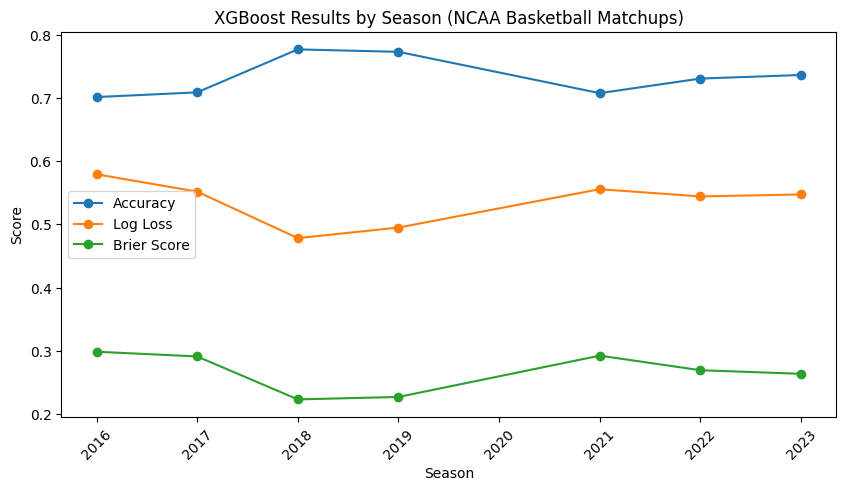

In [15]:
# Define features and target
FEATURES = [
    #     "WinPercentage",
    #     "MedianScoreDifference",
    #     "HighSeed",
    #     "OpponentWinPercentage",
    #     "OpponentMedianScoreDifference",
    #     "OpponentHighSeed",
    "WinPercentageDifference",
    "HighSeedDifference",
    #     "538rating",
    #     "538ratingOpponent",
    "538rating_Difference",
]
TARGET = "Win"

# Prepare data
x = df_features[FEATURES]
y = df_features[TARGET]
groups = df_features["Season"]
seasons = df_features["Season"].unique()

# Set up GroupKFold for cross-validation by season
gkf = GroupKFold(n_splits=len(seasons))

# Store results and models
cv_results = []
models = []


# Cross-validation loop
for season_idx, (train_index, test_index) in enumerate(gkf.split(x, y, groups)):
    holdout_season = seasons[season_idx]
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Define model
    model = xgb.XGBRegressor(
        eval_metric="logloss",
        n_estimators = 1337,
        learning_rate=0.001,
    )

    holdout_season = seasons[season_idx]
    print(f"Holdout Season: {holdout_season}")

    # Train model
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_test, y_test)],
        verbose = 0,
    )

    # Predict probabilities and class labels
    y_pred = model.predict(x_test)
    score_ll = log_loss(y_test, y_pred)
    y_pred = y_pred > 0.5

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)

    brier_score = brier_score_loss(y_test, y_pred)

    # Store results
    cv_results.append({
        "Season": holdout_season,
        "Accuracy": accuracy,
        "LogLoss": score_ll,
        "Brier Score": brier_score,
    })

    season_idx += 1
    print(f"Season {holdout_season}: {accuracy} {score_ll} {brier_score}")

    models.append(model)

# Display cross-validation results
df_cv_results = pd.DataFrame(cv_results)
display(df_cv_results)
print(f"\nAverage Accuracy: {df_cv_results['Accuracy'].mean():.4f}")
print(f"Average Log Loss: {df_cv_results['LogLoss'].mean():.4f}")
print(f"Average Brier Score: {df_cv_results['Brier Score'].mean():.4f}")

# Optional: Plot the results by season
plt.figure(figsize=(10, 5))
plt.plot(df_cv_results['Season'], df_cv_results['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_cv_results['Season'], df_cv_results['LogLoss'], marker='o', label='Log Loss')
plt.plot(df_cv_results['Season'], df_cv_results['Brier Score'], marker='o', label='Brier Score')
plt.xlabel("Season")
plt.ylabel("Score")
plt.title("XGBoost Results by Season (NCAA Basketball Matchups)")
plt.legend()
plt.xticks(rotation=45)
plt.show()
